
# Orbifold defect groups from Chen--Ruan sectors and fermionic quivers

Notebook used for the published papers arXiv:2404.17639, arXiv:2504.10484

We compute defect groups for non-supersymmetric 4D theories arising from orbifolds. We check these again geometric computations based on Chen-Ruan orbifold cohomology. We extend both to cover discrete torsion backgrounds.



## Functions 


1. `defect_group_from_chen_ruan(Gamma)` — degree-shifted Chen--Ruan/orbifold homology computation on \(S^5/\Gamma\).
2. `bps_quiver_from_fermions(Gamma)` — fermionic McKay quiver, adjacency matrix, Dirac pairing \(K=A_F-A_F^T\), and \(\mathrm{Tor}\,\mathrm{Coker}(K)\).
3. `compare_methods(Gamma)` — one-line consistency check between the geometric and quiver computations.
4. `second_group_cohomology(Gamma)` — \(H^2(\Gamma,U(1))\) for finite abelian \(\Gamma\).
5. `defect_group_with_discrete_torsion(Gamma, alpha)` — covering-space prescription for a discrete torsion element \(\alpha\).
6. `master_quiver(Gamma)` — the disjoint union over all discrete torsion choices.
7. `plot_quiver(...)` — a compact visualization of the quiver.



In [3]:

from __future__ import annotations

from dataclasses import dataclass
from fractions import Fraction
from itertools import product, combinations
from math import gcd, lcm
from typing import Any, Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
import sympy as sp
from sympy.matrices.normalforms import smith_normal_form

try:
    import matplotlib.pyplot as plt
    import networkx as nx
except Exception:  # networkx is optional for the algebraic computations
    plt = None
    nx = None

Element = Tuple[int, ...]


def _mod1(q: Fraction) -> Fraction:
    """Return q modulo 1 as a Fraction in [0,1)."""
    n = q.numerator // q.denominator
    r = q - n
    if r < 0:
        r += 1
    return r


def canonical_factors(factors: Iterable[int]) -> List[int]:
    """Canonical invariant factors for a direct sum of cyclic groups.

    Example: Z_2 ⊕ Z_3 is returned as [6].
    """
    factors = [abs(int(x)) for x in factors if abs(int(x)) > 1]
    if not factors:
        return []
    S = smith_normal_form(sp.diag(*factors), domain=sp.ZZ)
    out = []
    for i in range(min(S.shape)):
        d = abs(int(S[i, i]))
        if d > 1:
            out.append(d)
    return out


def coker_invariants_from_relation_matrix(M: Any) -> Tuple[List[int], int]:
    """Compute the torsion invariant factors and free rank of Z^n / rowspan(M)."""
    M = sp.Matrix(M)
    ncols = M.shape[1]
    if M.shape[0] == 0:
        return [], ncols
    S = smith_normal_form(M, domain=sp.ZZ)
    torsion = []
    rank = 0
    for i in range(min(S.shape)):
        d = abs(int(S[i, i]))
        if d != 0:
            rank += 1
            if d > 1:
                torsion.append(d)
    return canonical_factors(torsion), ncols - rank


def quotient_invariants(orders: Tuple[int, ...], subgroup_gens: Iterable[Element]) -> List[int]:
    """Invariant factors of (∏ Z_{orders[i]}) / <subgroup_gens>."""
    r = len(orders)
    rows = []
    for i, N in enumerate(orders):
        row = [0] * r
        row[i] = int(N)
        rows.append(row)
    for g in subgroup_gens:
        rows.append([int(x) % orders[i] for i, x in enumerate(g)])
    torsion, free_rank = coker_invariants_from_relation_matrix(rows)
    if free_rank:
        raise ValueError(f"quotient of a finite group unexpectedly has free rank {free_rank}")
    return torsion


def format_abelian_group(factors: Iterable[int], free_rank: int = 0, trivial: str = "trivial") -> str:
    """Pretty-print Z^free_rank plus finite cyclic invariant factors."""
    factors = canonical_factors(factors)
    pieces = []
    if free_rank == 1:
        pieces.append("Z")
    elif free_rank > 1:
        pieces.append(f"Z^{free_rank}")
    pieces += [f"Z_{n}" for n in factors]
    return " ⊕ ".join(pieces) if pieces else trivial


def cyclic_direct_sum(*groups: Iterable[int]) -> List[int]:
    """Canonical factors of a direct sum of finite abelian groups."""
    factors: List[int] = []
    for g in groups:
        factors.extend(list(g))
    return canonical_factors(factors)


In [4]:

@dataclass(frozen=True)
class CyclicSpinGenerator:
    """One cyclic generator acting diagonally on the spinor 4 of SU(4)."""
    order: int
    weights4: Tuple[int, int, int, int]
    name: str = "g"

    def __post_init__(self):
        if self.order <= 0:
            raise ValueError("generator order must be positive")
        if len(self.weights4) != 4:
            raise ValueError("weights4 must have length 4")
        raw = tuple(int(x) for x in self.weights4)
        object.__setattr__(self, "raw_weights4", raw)
        object.__setattr__(self, "weights4", tuple(x % self.order for x in raw))


class DiagonalAbelianSpinGroup:
    """Finite diagonal abelian subgroup of Spin(6) ≅ SU(4).

    Parameters
    ----------
    generators:
        List of CyclicSpinGenerator objects.  Each generator supplies an order and
        four spinor weights.
    name:
        Display name.
    """
    def __init__(self, generators: List[CyclicSpinGenerator], name: str = "Γ"):
        if not generators:
            raise ValueError("at least one generator is required")
        self.generators = list(generators)
        self.name = name
        self.orders = tuple(g.order for g in self.generators)
        self.rank = len(self.orders)
        self.weight_vectors4 = tuple(
            tuple(g.weights4[k] % g.order for g in self.generators) for k in range(4)
        )
        self.weight_vectors6 = tuple(
            tuple((self.weight_vectors4[i][a] + self.weight_vectors4[j][a]) % self.orders[a]
                  for a in range(self.rank))
            for i, j in combinations(range(4), 2)
        )

    @property
    def order(self) -> int:
        out = 1
        for N in self.orders:
            out *= N
        return out

    def __repr__(self) -> str:
        pieces = [f"Z_{g.order}{g.raw_weights4}" for g in self.generators]
        return f"{self.name} = " + " × ".join(pieces)

    def elements(self) -> List[Element]:
        return list(product(*[range(N) for N in self.orders]))

    def identity(self) -> Element:
        return tuple(0 for _ in self.orders)

    def add(self, a: Element, b: Element) -> Element:
        return tuple((a[i] + b[i]) % self.orders[i] for i in range(self.rank))

    def neg(self, a: Element) -> Element:
        return tuple((-a[i]) % self.orders[i] for i in range(self.rank))

    def element_order(self, a: Element) -> int:
        m = 1
        for ai, Ni in zip(a, self.orders):
            if ai % Ni:
                m = lcm(m, Ni // gcd(Ni, ai))
        return m

    def spinor_phases(self, a: Element) -> Tuple[Fraction, Fraction, Fraction, Fraction]:
        phases = []
        for k in range(4):
            q = Fraction(0, 1)
            for coeff, gen in zip(a, self.generators):
                q += Fraction(coeff * gen.weights4[k], gen.order)
            phases.append(_mod1(q))
        return tuple(phases)

    def vector_phases(self, a: Element) -> Tuple[Fraction, Fraction, Fraction]:
        """Phases on the chosen holomorphic C^3 coordinates."""
        s = self.spinor_phases(a)
        return tuple(_mod1(s[i] + s[3]) for i in range(3))

    def fixed_coordinates(self, a: Element) -> Tuple[int, ...]:
        return tuple(i for i, q in enumerate(self.vector_phases(a)) if q == 0)

    def age(self, a: Element) -> Fraction:
        """Chen--Ruan age of a sector in the local C^3 model."""
        fixed = set(self.fixed_coordinates(a))
        return sum((q for i, q in enumerate(self.vector_phases(a)) if i not in fixed), Fraction(0, 1))

    def has_fixed_points_on_s5(self, a: Element) -> bool:
        return len(self.fixed_coordinates(a)) > 0

    def gso_ok(self) -> bool:
        """Generator-wise type-II GSO parity check in the conventions of the papers."""
        for gen in self.generators:
            s1, s2, s3, s4 = gen.raw_weights4
            if (s1 + s2 + s3 + 3 * s4) % 2 != 0:
                return False
        return True

    def su3_vector_sum_zero(self) -> bool:
        """True if each generator acts with determinant one on the chosen C^3."""
        for gen in self.generators:
            v = [(gen.weights4[i] + gen.weights4[3]) % gen.order for i in range(3)]
            if sum(v) % gen.order != 0:
                return False
        return True

    def fixed_sector_summary(self) -> Dict[Tuple[int, ...], int]:
        """Count sectors by fixed coordinate set.  The identity contributes (0,1,2)."""
        out: Dict[Tuple[int, ...], int] = {}
        for g in self.elements():
            coords = self.fixed_coordinates(g)
            if g == self.identity() or coords:
                out[coords] = out.get(coords, 0) + 1
        return out

    # ---------- Chen--Ruan / boundary-side calculation ----------

    def _fixed_nontrivial_elements(self) -> List[Element]:
        e = self.identity()
        return [g for g in self.elements() if g != e and self.has_fixed_points_on_s5(g)]

    def h1_s5_quotient(self) -> List[int]:
        """H_1(S^5/Gamma) = Gamma / Gamma_fix by Armstrong's theorem."""
        return quotient_invariants(self.orders, self._fixed_nontrivial_elements())

    def h1_s3_quotient_for_pair(self, coords: Tuple[int, int]) -> List[int]:
        """H_1 of a codimension-2 fixed S^3/Gamma sector."""
        i, j = coords
        subgroup_gens = []
        for h in self.elements():
            phases = self.vector_phases(h)
            if phases[i] == 0 or phases[j] == 0:
                subgroup_gens.append(h)
        return quotient_invariants(self.orders, subgroup_gens)

    def chen_ruan_boundary_data(self) -> Dict[str, Any]:
        """Combinatorial degree-shifted CR computation on S^5/Gamma.

        The line-defect group is returned as
            D^(1) = Tor H_orb_1(S^5/Gamma) ⊕ Tor H_orb_1(S^5/Gamma)^∨.
        For finite abelian groups, the Pontryagin dual has the same invariant factors.
        """
        identity = self.identity()
        fixed_nontrivial = self._fixed_nontrivial_elements()

        # Untwisted H_1(S^5/Gamma).
        gamma_over_fix = quotient_invariants(self.orders, fixed_nontrivial)
        gamma_invariants = quotient_invariants(self.orders, [])

        # Twisted codimension-2 sectors: inverse pairs contribute H_1(S^3/Gamma).
        codim2_contribs: List[int] = []
        visited = set()
        for g in fixed_nontrivial:
            if g in visited:
                continue
            inv = self.neg(g)
            visited.add(g)
            visited.add(inv)
            coords = self.fixed_coordinates(g)
            if len(coords) == 2:
                codim2_contribs.extend(self.h1_s3_quotient_for_pair(coords))

        tor_horb1 = cyclic_direct_sum(gamma_over_fix, codim2_contribs)
        tor_horb3 = cyclic_direct_sum(gamma_invariants, codim2_contribs)
        defect = cyclic_direct_sum(tor_horb1, tor_horb1)

        return {
            "group_order": self.order,
            "group_invariants": gamma_invariants,
            "gamma_over_fix": gamma_over_fix,
            "tor_Horb1": tor_horb1,
            "tor_Horb3": tor_horb3,
            "codim2_contribs": canonical_factors(codim2_contribs),
            "defect_D1": defect,
            "free_rank_coker": len(fixed_nontrivial) + 1,
            "n_twisted_nonempty": len(fixed_nontrivial),
            "fixed_sector_summary": self.fixed_sector_summary(),
        }

    # ---------- quiver-side calculation ----------

    def adjacency_matrix(self, rep: str = "fermion") -> Tuple[np.ndarray, List[Element]]:
        """McKay adjacency matrix for the 4 (fermions) or 6 (bosons)."""
        nodes = self.elements()  # irreducible characters of the abelian group
        idx = {g: i for i, g in enumerate(nodes)}
        A = np.zeros((len(nodes), len(nodes)), dtype=int)
        weights = self.weight_vectors4 if rep.lower().startswith("f") else self.weight_vectors6
        for node in nodes:
            i = idx[node]
            for w in weights:
                target = tuple((node[a] + w[a]) % self.orders[a] for a in range(self.rank))
                A[i, idx[target]] += 1
        return A, nodes

    def quiver_data(self) -> Dict[str, Any]:
        AF, nodes = self.adjacency_matrix("fermion")
        AB, _ = self.adjacency_matrix("boson")
        K = AF - AF.T
        torsion, free_rank = coker_invariants_from_relation_matrix(K)
        return {
            "nodes": nodes,
            "A_fermion": AF,
            "A_boson": AB,
            "K": K,
            "coker_torsion": torsion,
            "coker_free_rank": free_rank,
            "defect_D1": torsion,
        }

    # ---------- discrete torsion ----------

    def h2_discrete_torsion(self) -> Dict[str, Any]:
        """H^2(Gamma,U(1)) for finite abelian Gamma = product Z_N."""
        pairs, moduli = [], []
        for i in range(self.rank):
            for j in range(i + 1, self.rank):
                m = gcd(self.orders[i], self.orders[j])
                if m > 1:
                    pairs.append((i, j))
                    moduli.append(m)
        return {"pairs": pairs, "moduli": moduli, "invariants": canonical_factors(moduli)}

    def discrete_torsion_elements(self) -> List[Tuple[int, ...]]:
        data = self.h2_discrete_torsion()
        if not data["moduli"]:
            return [tuple()]
        return list(product(*[range(m) for m in data["moduli"]]))

    def discrete_torsion_order(self, alpha: Tuple[int, ...]) -> int:
        data = self.h2_discrete_torsion()
        if len(alpha) != len(data["moduli"]):
            raise ValueError("alpha has the wrong length for H^2(Gamma,U(1))")
        out = 1
        for a, m in zip(alpha, data["moduli"]):
            a = int(a) % m
            if a:
                out = lcm(out, m // gcd(a, m))
        return out

    def _alpha_phase(self, alpha: Tuple[int, ...], g: Element, h: Element) -> Fraction:
        """Alternating bicharacter associated to alpha, returned modulo 1."""
        data = self.h2_discrete_torsion()
        q = Fraction(0, 1)
        for a, (i, j), m in zip(alpha, data["pairs"], data["moduli"]):
            q += Fraction(int(a) * (g[i] * h[j] - g[j] * h[i]), m)
        return _mod1(q)

    def kernel_of_discrete_torsion(self, alpha: Tuple[int, ...]) -> List[Element]:
        """Kernel Gamma_alpha of the alternating form associated to alpha."""
        if not alpha or all(a == 0 for a in alpha):
            return self.elements()
        basis = []
        for i, N in enumerate(self.orders):
            e = [0] * self.rank
            e[i] = 1 % N
            basis.append(tuple(e))
        return [g for g in self.elements() if all(self._alpha_phase(alpha, g, e) == 0 for e in basis)]

    def subgroup_closure(self, gens: Iterable[Element]) -> set[Element]:
        gens = [tuple(g[i] % self.orders[i] for i in range(self.rank)) for g in gens]
        closure = {self.identity()}
        changed = True
        while changed:
            changed = False
            for x in list(closure):
                for g in gens:
                    y = self.add(x, g)
                    if y not in closure:
                        closure.add(y)
                        changed = True
        return closure

    def independent_generators_for_subgroup(self, subgroup_elems: List[Element]) -> List[Element]:
        """Find independent cyclic generators whose product of orders equals subgroup size."""
        target = set(subgroup_elems)
        if target == {self.identity()}:
            return []
        candidates = [g for g in subgroup_elems if g != self.identity()]
        candidates.sort(key=lambda x: self.element_order(x), reverse=True)
        best = None

        def dfs(start: int, gens: List[Element], closure: set[Element], prod_orders: int) -> bool:
            nonlocal best
            if closure == target and prod_orders == len(target):
                best = list(gens)
                return True
            if prod_orders > len(target) or len(gens) > self.rank + 2:
                return False
            for idx in range(start, len(candidates)):
                c = candidates[idx]
                if c in closure:
                    continue
                new_gens = gens + [c]
                new_closure = self.subgroup_closure(new_gens)
                if not new_closure.issubset(target):
                    continue
                new_prod = prod_orders * self.element_order(c)
                if len(new_closure) != new_prod:  # dependence check
                    continue
                if dfs(idx + 1, new_gens, new_closure, new_prod):
                    return True
            return False

        dfs(0, [], {self.identity()}, 1)
        if best is None:
            raise RuntimeError("could not find independent generators for subgroup")
        return best

    def covering_group_for_discrete_torsion(self, alpha: Tuple[int, ...]) -> "DiagonalAbelianSpinGroup":
        """Covering group Gamma_alpha used in the discrete-torsion prescription."""
        alpha = tuple(int(a) for a in alpha)
        if not alpha or all(a == 0 for a in alpha):
            return self
        ker = self.kernel_of_discrete_torsion(alpha)
        gens = self.independent_generators_for_subgroup(ker)
        cyclics: List[CyclicSpinGenerator] = []
        for idx, g in enumerate(gens):
            m = self.element_order(g)
            phases = self.spinor_phases(g)
            weights = []
            for q in phases:
                val = q * m
                if val.denominator != 1:
                    raise RuntimeError("kernel generator phase did not have the expected order")
                weights.append(int(val) % m)
            cyclics.append(CyclicSpinGenerator(m, tuple(weights), name=f"k{idx}"))
        if not cyclics:
            cyclics = [CyclicSpinGenerator(1, (0, 0, 0, 0), name="trivial")]
        return DiagonalAbelianSpinGroup(cyclics, name=f"{self.name}_α{alpha}")

    def defect_with_discrete_torsion(self, alpha: Tuple[int, ...]) -> Dict[str, Any]:
        cover = self.covering_group_for_discrete_torsion(alpha)
        data = cover.chen_ruan_boundary_data()
        data.update({
            "alpha": alpha,
            "alpha_order": self.discrete_torsion_order(alpha),
            "covering_group": cover,
        })
        return data

    def master_quiver(self) -> Dict[str, Any]:
        """Disjoint union of quivers over all alpha in H^2(Gamma,U(1))."""
        components = []
        blocks = []
        for alpha in self.discrete_torsion_elements():
            cover = self.covering_group_for_discrete_torsion(alpha)
            q = cover.quiver_data()
            components.append({
                "alpha": alpha,
                "alpha_order": self.discrete_torsion_order(alpha),
                "covering_group": cover,
                **q,
            })
            blocks.append(sp.Matrix(q["A_fermion"]))
        A_master = sp.diag(*blocks) if blocks else sp.zeros(0)
        K_master = A_master - A_master.T
        torsion, free_rank = coker_invariants_from_relation_matrix(K_master)
        return {
            "components": components,
            "A_fermion_master": np.array(A_master.tolist(), dtype=int),
            "K_master": np.array(K_master.tolist(), dtype=int),
            "coker_torsion": torsion,
            "coker_free_rank": free_rank,
        }


def make_group(generator_specs: List[Tuple[int, Tuple[int, int, int, int]]], name: str = "Γ") -> DiagonalAbelianSpinGroup:
    """Constructor from a list of `(order, weights_on_4)` pairs."""
    return DiagonalAbelianSpinGroup(
        [CyclicSpinGenerator(N, tuple(w), name=f"g{i}") for i, (N, w) in enumerate(generator_specs)],
        name=name,
    )


def cyclic_group(order: int, weights4: Tuple[int, int, int, int], name: str = "Γ") -> DiagonalAbelianSpinGroup:
    return make_group([(order, weights4)], name=name)


In [5]:

#API wrappers

def defect_group_from_chen_ruan(Gamma: DiagonalAbelianSpinGroup) -> Dict[str, Any]:
    return Gamma.chen_ruan_boundary_data()


def bps_quiver_from_fermions(Gamma: DiagonalAbelianSpinGroup) -> Dict[str, Any]:
    return Gamma.quiver_data()


def second_group_cohomology(Gamma: DiagonalAbelianSpinGroup) -> Dict[str, Any]:
    return Gamma.h2_discrete_torsion()


def defect_group_with_discrete_torsion(Gamma: DiagonalAbelianSpinGroup, alpha: Tuple[int, ...]) -> Dict[str, Any]:
    return Gamma.defect_with_discrete_torsion(alpha)


def master_quiver(Gamma: DiagonalAbelianSpinGroup) -> Dict[str, Any]:
    return Gamma.master_quiver()


def compare_methods(Gamma: DiagonalAbelianSpinGroup) -> Dict[str, Any]:
    cr = defect_group_from_chen_ruan(Gamma)
    qv = bps_quiver_from_fermions(Gamma)
    return {
        "Gamma": repr(Gamma),
        "CR defect": format_abelian_group(cr["defect_D1"]),
        "quiver defect": format_abelian_group(qv["defect_D1"]),
        "CR free rank": cr["free_rank_coker"],
        "quiver free rank": qv["coker_free_rank"],
        "match": cr["defect_D1"] == qv["defect_D1"] and cr["free_rank_coker"] == qv["coker_free_rank"],
    }


def symmetry_theory_skeleton(Gamma: DiagonalAbelianSpinGroup, alpha: Tuple[int, ...] | None = None) -> Dict[str, Any]:
    """A lightweight summary of the finite BF sectors and free U(1) rank.

    This is not a full linking-form computation.  It is a useful checklist for what fields
    a full SymTh reduction needs to include.
    """
    data = Gamma.defect_with_discrete_torsion(alpha) if alpha is not None else Gamma.chen_ruan_boundary_data()
    return {
        "finite 1-form defect group D^(1)": format_abelian_group(data["defect_D1"]),
        "Tor H_orb_1": format_abelian_group(data["tor_Horb1"]),
        "Tor H_orb_3": format_abelian_group(data["tor_Horb3"]),
        "free rank in Coker(K)": data["free_rank_coker"],
        "twisted sectors with fixed locus": data["n_twisted_nonempty"],
    }


In [6]:

def plot_quiver(A: np.ndarray, nodes: List[Element] | None = None, title: str = "fermionic quiver", max_edge_labels: int = 80):
    """Draw a weighted directed quiver from an adjacency matrix."""
    if plt is None or nx is None:
        print("matplotlib/networkx not available; returning adjacency matrix only")
        return A
    A = np.asarray(A, dtype=int)
    n = A.shape[0]
    labels = {i: str(nodes[i]) if nodes is not None and n <= 24 else str(i) for i in range(n)}
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(n):
            if A[i, j] != 0:
                G.add_edge(i, j, weight=int(A[i, j]))
    pos = nx.circular_layout(G)
    fig, ax = plt.subplots(figsize=(6, 6))
    nx.draw_networkx_nodes(G, pos, node_size=600 if n <= 20 else 220, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8 if n <= 20 else 6, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", width=1.0, alpha=0.75,
                           connectionstyle="arc3,rad=0.08", ax=ax)
    if G.number_of_edges() <= max_edge_labels:
        edge_labels = {(u, v): d["weight"] for u, v, d in G.edges(data=True) if d["weight"] != 1}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax)
    ax.set_title(title)
    ax.axis("off")
    plt.show()
    return fig



## Example 1: A cyclic non-SUSY orbifold

The input is exactly the promised format: a list of generators, each given by an order and four spinor weights.


In [7]:

Gamma5 = cyclic_group(5, (1, 1, 1, -3), name="Γ_5")
print(Gamma5)
print("type-II GSO parity check:", Gamma5.gso_ok())
print("vector phases of generator:", Gamma5.vector_phases((1,)))

cr5 = defect_group_from_chen_ruan(Gamma5)
q5 = bps_quiver_from_fermions(Gamma5)

print("CR defect group D^(1):", format_abelian_group(cr5["defect_D1"]))
print("quiver defect group Tor Coker(K):", format_abelian_group(q5["defect_D1"]))
print("free rank in Coker(K):", q5["coker_free_rank"])


Γ_5 = Z_5(1, 1, 1, -3)
type-II GSO parity check: True
vector phases of generator: (Fraction(3, 5), Fraction(3, 5), Fraction(3, 5))
CR defect group D^(1): Z_5 ⊕ Z_5
quiver defect group Tor Coker(K): Z_5 ⊕ Z_5
free rank in Coker(K): 1


In [8]:

# The adjacency matrix for the fermionic quiver and a picture of the quiver.
pd.DataFrame(q5["A_fermion"], index=q5["nodes"], columns=q5["nodes"])


,"(0,)","(1,)","(2,)","(3,)","(4,)"
"(0,)",0,3,1,0,0
"(1,)",0,0,3,1,0
"(2,)",0,0,0,3,1
"(3,)",1,0,0,0,3
"(4,)",3,1,0,0,0


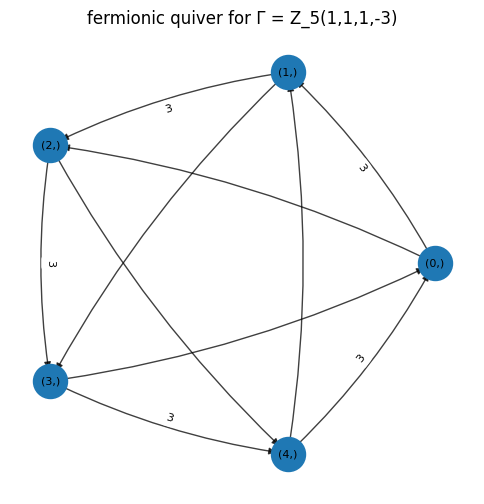

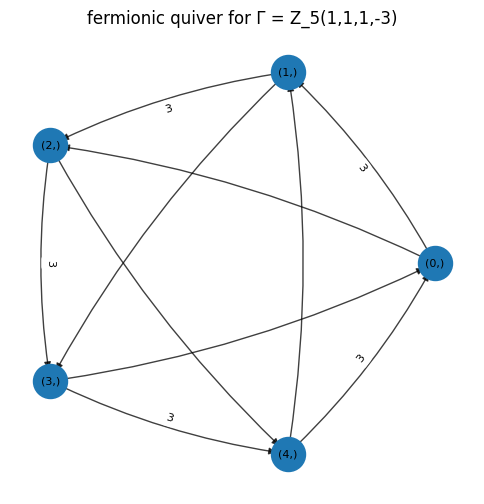

In [9]:

plot_quiver(q5["A_fermion"], q5["nodes"], title="fermionic quiver for Γ = Z_5(1,1,1,-3)")



## Checks (see paper)

The next table checks the geometry-side Chen--Ruan computation against the fermionic quiver computation.  Free rank of the cokernel also included.


In [10]:

examples = [
    ("Z5  (1,1,1,-3)", cyclic_group(5,  (1, 1, 1, -3),       name="Γ")),
    ("Z17 (4,6,-7,-3)", cyclic_group(17, (4, 6, -7, -3),      name="Γ")),
    ("Z9  (2,3,-4,-1)", cyclic_group(9,  (2, 3, -4, -1),      name="Γ")),
    ("Z9  (3,5,-6,-2)", cyclic_group(9,  (3, 5, -6, -2),      name="Γ")),
    ("Z9  (-4,-2,1,5)", cyclic_group(9,  (-4, -2, 1, 5),      name="Γ")),
    ("Z6  (1,0,1,4)",   cyclic_group(6,  (1, 0, 1, 4),        name="Γ")),
]

rows = []
for label, G in examples:
    row = compare_methods(G)
    row["example"] = label
    row["Tor H_orb_1"] = format_abelian_group(defect_group_from_chen_ruan(G)["tor_Horb1"])
    row["fixed-sector summary"] = defect_group_from_chen_ruan(G)["fixed_sector_summary"]
    rows.append(row)

check_table = pd.DataFrame(rows)[[
    "example", "Tor H_orb_1", "CR defect", "quiver defect",
    "CR free rank", "quiver free rank", "match", "fixed-sector summary"
]]
check_table


,example,Tor H_orb_1,CR defect,quiver defect,CR free rank,quiver free rank,match,fixed-sector summary
0,"Z5 (1,1,1,-3)",Z_5,Z_5 ⊕ Z_5,Z_5 ⊕ Z_5,1,1,True,"{(0, 1, 2): 1}"
1,"Z17 (4,6,-7,-3)",Z_17,Z_17 ⊕ Z_17,Z_17 ⊕ Z_17,1,1,True,"{(0, 1, 2): 1}"
2,"Z9 (2,3,-4,-1)",Z_9,Z_9 ⊕ Z_9,Z_9 ⊕ Z_9,1,1,True,"{(0, 1, 2): 1}"
3,"Z9 (3,5,-6,-2)",Z_3,Z_3 ⊕ Z_3,Z_3 ⊕ Z_3,3,3,True,"{(0, 1, 2): 1, (1,): 2}"
4,"Z9 (-4,-2,1,5)",Z_3 ⊕ Z_3,Z_3 ⊕ Z_3 ⊕ Z_3 ⊕ Z_3,Z_3 ⊕ Z_3 ⊕ Z_3 ⊕ Z_3,3,3,True,"{(0, 1, 2): 1, (1, 2): 2}"
5,"Z6 (1,0,1,4)",Z_3,Z_3 ⊕ Z_3,Z_3 ⊕ Z_3,2,2,True,"{(0, 1, 2): 1, (1,): 1}"



## Discrete torsion and \(H^2(\Gamma,U(1))\)

For a finite abelian group \(\Gamma=\prod_i \mathbb Z_{N_i}\), the Schur multiplier is

\[
H^2(\Gamma,U(1))\simeq \prod_{i<j}\mathbb Z_{\gcd(N_i,N_j)}.
\]

The discrete-torsion calculation below uses the covering-space prescription \(X_\alpha=\mathbb R^6/\Gamma_\alpha\), where \(\Gamma_\alpha\) is the kernel of the alternating bicharacter associated to \(\alpha\).


In [11]:

Gamma_8x2 = make_group([
    (8, (4, 2, 1, 1)),
    (2, (1, 0, 1, 0)),
], name="Γ = Z8 × Z2")

h2 = second_group_cohomology(Gamma_8x2)
print(Gamma_8x2)
print("H^2 invariants:", format_abelian_group(h2["invariants"]))
print("coordinate moduli for alpha:", h2["moduli"])
print("all alpha:", Gamma_8x2.discrete_torsion_elements())


Γ = Z8 × Z2 = Z_8(4, 2, 1, 1) × Z_2(1, 0, 1, 0)
H^2 invariants: Z_2
coordinate moduli for alpha: [2]
all alpha: [(0,), (1,)]


In [12]:

rows = []
for alpha in Gamma_8x2.discrete_torsion_elements():
    d = defect_group_with_discrete_torsion(Gamma_8x2, alpha)
    q = d["covering_group"].quiver_data()
    rows.append({
        "alpha": alpha,
        "ord(alpha)": d["alpha_order"],
        "covering group Γ_alpha": repr(d["covering_group"]),
        "CR defect D^(1)_alpha": format_abelian_group(d["defect_D1"]),
        "quiver defect": format_abelian_group(q["defect_D1"]),
        "free rank": d["free_rank_coker"],
        "component match": d["defect_D1"] == q["defect_D1"] and d["free_rank_coker"] == q["coker_free_rank"],
    })

pd.DataFrame(rows)


,alpha,ord(alpha),covering group Γ_alpha,CR defect D^(1)_alpha,quiver defect,free rank,component match
0,"(0,)",1,"Γ = Z8 × Z2 = Z_8(4, 2, 1, 1) × Z_2(1, 0, 1, 0)",Z_2 ⊕ Z_2,Z_2 ⊕ Z_2,6,True
1,"(1,)",2,"Γ = Z8 × Z2_α(1,) = Z_4(0, 2, 1, 1)",Z_2 ⊕ Z_2,Z_2 ⊕ Z_2,2,True



## Master quiver

The master quiver is the disjoint union over all \(\alpha\in H^2(\Gamma,U(1))\).  In this implementation, each component is built from the covering group \(\Gamma_\alpha\).


In [13]:

M = master_quiver(Gamma_8x2)
component_rows = []
for c in M["components"]:
    component_rows.append({
        "alpha": c["alpha"],
        "nodes": len(c["nodes"]),
        "covering group": repr(c["covering_group"]),
        "component coker": format_abelian_group(c["coker_torsion"], c["coker_free_rank"]),
    })

print("master adjacency matrix shape:", M["A_fermion_master"].shape)
print("master coker:", format_abelian_group(M["coker_torsion"], M["coker_free_rank"]))
pd.DataFrame(component_rows)


master adjacency matrix shape: (20, 20)
master coker: Z^8 ⊕ Z_2 ⊕ Z_2 ⊕ Z_2 ⊕ Z_2


,alpha,nodes,covering group,component coker
0,"(0,)",16,"Γ = Z8 × Z2 = Z_8(4, 2, 1, 1) × Z_2(1, 0, 1, 0)",Z^6 ⊕ Z_2 ⊕ Z_2
1,"(1,)",4,"Γ = Z8 × Z2_α(1,) = Z_4(0, 2, 1, 1)",Z^2 ⊕ Z_2 ⊕ Z_2


In [14]:

# Check: direct sum of all covering-space component cokernels equals the master coker.
component_torsion = []
component_free = 0
for c in M["components"]:
    component_torsion.extend(c["coker_torsion"])
    component_free += c["coker_free_rank"]

print("direct-sum coker from components:", format_abelian_group(component_torsion, component_free))
print("master-quiver coker:           ", format_abelian_group(M["coker_torsion"], M["coker_free_rank"]))
assert canonical_factors(component_torsion) == M["coker_torsion"]
assert component_free == M["coker_free_rank"]


direct-sum coker from components: Z^8 ⊕ Z_2 ⊕ Z_2 ⊕ Z_2 ⊕ Z_2
master-quiver coker:            Z^8 ⊕ Z_2 ⊕ Z_2 ⊕ Z_2 ⊕ Z_2


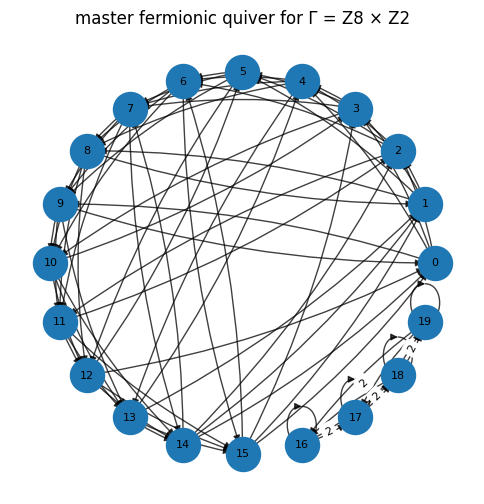

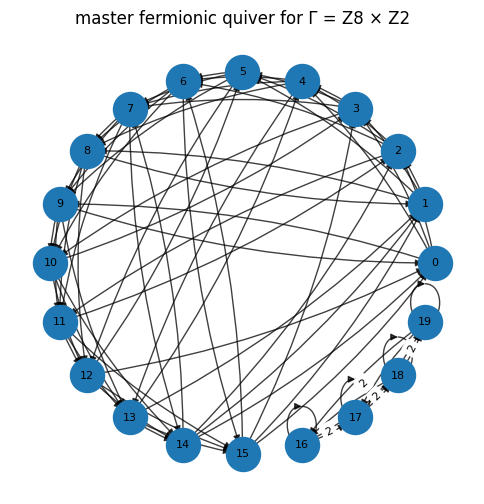

In [15]:

plot_quiver(M["A_fermion_master"], title="master fermionic quiver for Γ = Z8 × Z2")



## A larger discrete-torsion check: \(\mathbb Z_9\times\mathbb Z_3\)

This example has three discrete torsion choices.  The two nontrivial choices have the same order and therefore give isomorphic covering-space quivers.


In [16]:

Gamma_9x3 = make_group([
    (9, (2, 0, 1, 6)),
    (3, (0, 1, 0, 2)),
], name="Γ = Z9 × Z3")

rows = []
for alpha in Gamma_9x3.discrete_torsion_elements():
    d = defect_group_with_discrete_torsion(Gamma_9x3, alpha)
    rows.append({
        "alpha": alpha,
        "ord(alpha)": d["alpha_order"],
        "covering group": repr(d["covering_group"]),
        "D^(1)_alpha": format_abelian_group(d["defect_D1"]),
        "free rank": d["free_rank_coker"],
        "Tor H_orb_1": format_abelian_group(d["tor_Horb1"]),
    })

pd.DataFrame(rows)


,alpha,ord(alpha),covering group,D^(1)_alpha,free rank,Tor H_orb_1
0,"(0,)",1,"Γ = Z9 × Z3 = Z_9(2, 0, 1, 6) × Z_3(0, 1, 0, 2)",Z_3 ⊕ Z_3 ⊕ Z_3 ⊕ Z_3 ⊕ Z_3 ⊕ Z_3,9,Z_3 ⊕ Z_3 ⊕ Z_3
1,"(1,)",3,"Γ = Z9 × Z3_α(1,) = Z_3(2, 0, 1, 0)",trivial,3,trivial
2,"(2,)",3,"Γ = Z9 × Z3_α(2,) = Z_3(2, 0, 1, 0)",trivial,3,trivial


In [17]:

M93 = master_quiver(Gamma_9x3)
component_torsion = []
component_free = 0
for c in M93["components"]:
    component_torsion.extend(c["coker_torsion"])
    component_free += c["coker_free_rank"]

print("H^2:", format_abelian_group(second_group_cohomology(Gamma_9x3)["invariants"]))
print("master adjacency matrix shape:", M93["A_fermion_master"].shape)
print("direct-sum coker from all alpha:", format_abelian_group(component_torsion, component_free))
print("master-quiver coker:          ", format_abelian_group(M93["coker_torsion"], M93["coker_free_rank"]))
assert canonical_factors(component_torsion) == M93["coker_torsion"]
assert component_free == M93["coker_free_rank"]


H^2: Z_3
master adjacency matrix shape: (33, 33)
direct-sum coker from all alpha: Z^15 ⊕ Z_3 ⊕ Z_3 ⊕ Z_3 ⊕ Z_3 ⊕ Z_3 ⊕ Z_3
master-quiver coker:           Z^15 ⊕ Z_3 ⊕ Z_3 ⊕ Z_3 ⊕ Z_3 ⊕ Z_3 ⊕ Z_3


In [18]:

G_diag = cyclic_group(9, (-4, -2, 1, 5), name="Γ_diag")
print(G_diag)
print("fixed sector summary:", G_diag.fixed_sector_summary())
print("age of generator:", G_diag.age((1,)))
print("GSO parity check:", G_diag.gso_ok())
print("SU(3) subcase:", G_diag.su3_vector_sum_zero())
symmetry_theory_skeleton(G_diag)


Γ_diag = Z_9(-4, -2, 1, 5)
fixed sector summary: {(0, 1, 2): 1, (1, 2): 2}
age of generator: 10/9
GSO parity check: True
SU(3) subcase: False


{'finite 1-form defect group D^(1)': 'Z_3 ⊕ Z_3 ⊕ Z_3 ⊕ Z_3',
 'Tor H_orb_1': 'Z_3 ⊕ Z_3',
 'Tor H_orb_3': 'Z_3 ⊕ Z_9',
 'free rank in Coker(K)': 3,
 'twisted sectors with fixed locus': 2}